# Notebook 8 — Distribution Analysis

**Distribution analysis** is the process of examining how data values are spread across a range to understand patterns, central tendencies, and variability

### Telecom Customer Churn Dataset

**Features analyzed:** `tenure_months`, `monthly_charges`, `total_charges`
(the numeric columns that carry meaningful continuous information; `senior_citizen` is a
binary flag, not a continuous distribution, so it is excluded from shape analysis).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('telecom_customer_churn.csv')
df.shape

(1015, 14)

## 1. Quick Look at the Data

In [2]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-10681,Male,0,Yes,No,24.00,Yes,Fiber optic,Month-to-month,Yes,Credit card,80.04,"1,900.19",No
1,CUST-10024,Female,0,Yes,No,35.00,Yes,Fiber optic,Month-to-month,Yes,Mailed check,42.99,"1,539.83",No
2,CUST-10621,Male,0,Yes,No,68.00,Yes,DSL,Month-to-month,Yes,Electronic check,79.31,"5,401.35",Yes
3,CUST-10099,Male,0,Yes,Yes,18.00,Yes,Fiber optic,Month-to-month,Yes,Electronic check,113.02,"2,022.80",No
4,CUST-10284,Male,1,Yes,Yes,34.00,Yes,No,Month-to-month,No,Electronic check,28.78,966.99,Yes


In [3]:
df[['tenure_months', 'monthly_charges', 'total_charges']].describe()

,tenure_months,monthly_charges,total_charges
count,"1,005.00","1,015.00",985.00
mean,34.26,69.29,"2,360.99"
std,21.14,30.13,"1,883.59"
min,0.00,-97.93,0.00
25%,16.00,44.39,867.59
50%,34.00,70.09,"1,849.21"
75%,52.00,94.37,"3,486.55"
max,72.00,119.45,"8,354.36"


**Observations from `describe()`:**
- `tenure_months` ranges 0–72 months (0 to 6 years), consistent with a typical contract dataset.
- `monthly_charges` has a **minimum of a negative value**, which is not physically possible for a
  bill amount — this is a data-quality issue we'll flag as an outlier/error later.
- `total_charges` ranges from 0 up to ~8,354, with a mean (2,361) noticeably higher than the
  median (1,849) — an early hint of **right skew**.
- All three columns have some missing values, which we handle below (rows are dropped only for the
  purpose of the distribution plots, not mutating the original dataframe).


## 2. Handling Missing Values and Data Issues

Before analyzing shape, we take a clean copy of each column (dropping NaNs) so that missing data
doesn't distort the statistics. We also flag the negative `monthly_charges` value.

In [4]:
num_cols = ['tenure_months', 'monthly_charges', 'total_charges']

print('Missing values:')
print(df[num_cols].isna().sum())

print('\nNegative monthly_charges rows:')
print(df[df['monthly_charges'] < 0][['customer_id', 'monthly_charges']])

Missing values:
tenure_months      10
monthly_charges     0
total_charges      30
dtype: int64

Negative monthly_charges rows:
    customer_id  monthly_charges
443  CUST-10221           -97.93
782  CUST-10576           -20.30
917  CUST-10130           -84.27


We'll keep the negative value visible in the raw distribution plots (so it shows up as a
clear outlier / data-entry error), but we will point it out explicitly in the outlier section
rather than silently deleting data.

## 3. Distribution Shape — Histograms with KDE

A histogram with a kernel density estimate (KDE) overlay lets us see the overall **shape** of a
distribution: whether it looks *symmetric* (bell-shaped / normal-like), *uniform* (flat), or
*skewed* (a long tail pulling to one side).

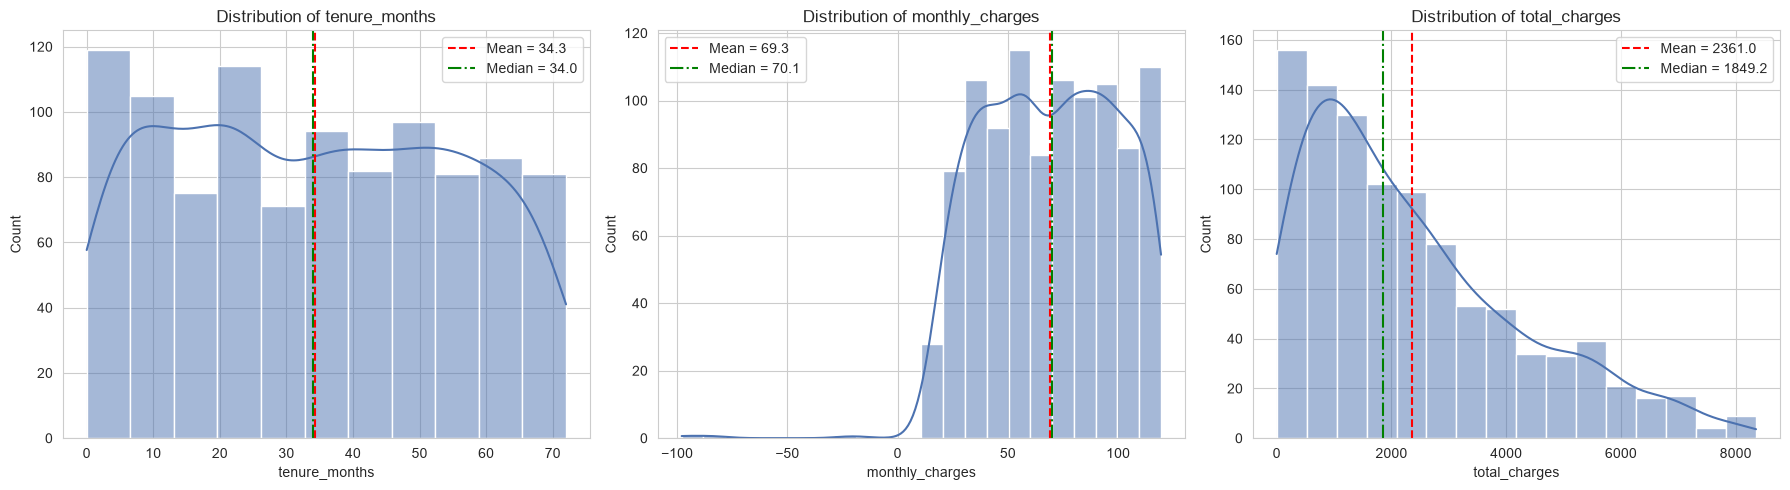

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    data = df[col].dropna()
    sns.histplot(data, kde=True, ax=ax, color='#4C72B0', edgecolor='white')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean = {data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle='-.', label=f'Median = {data.median():.1f}')
    ax.set_title(f'Distribution of {col}')
    ax.legend()

plt.tight_layout()
plt.show()

**Reading the histograms:**

- **`tenure_months`** — Looks close to a **uniform-ish / fairly flat** distribution across the
  0–72 month range, with mean and median close together. There is no strong single peak, unlike a
  normal distribution which would cluster tightly around the center.
- **`monthly_charges`** — Roughly **bimodal / spread out**, with a mean and median that are close,
  suggesting near-**symmetric** behavior overall, aside from the negative outlier.
- **`total_charges`** — Clearly **right-skewed (positively skewed)**: a tall concentration of low
  values with a long tail stretching toward high values, and mean > median confirms this.


## 4. Skewness and Kurtosis

- **Skewness** measures asymmetry.
  - `skew ≈ 0` → symmetric distribution
  - `skew > 0` → **right-skewed** (long tail to the right; mean > median)
  - `skew < 0` → **left-skewed** (long tail to the left; mean < median)
- **Kurtosis** (excess kurtosis, normal = 0) measures "tailedness"/peakedness.
  - `kurtosis ≈ 0` → normal-like tails (mesokurtic)
  - `kurtosis > 0` → heavier tails / more outlier-prone (leptokurtic)
  - `kurtosis < 0` → lighter tails / flatter than normal (platykurtic)

In [6]:
summary_rows = []
for col in num_cols:
    data = df[col].dropna()
    summary_rows.append({
        'feature': col,
        'mean': data.mean(),
        'median': data.median(),
        'std_dev': data.std(),
        'skewness': stats.skew(data),
        'kurtosis_excess': stats.kurtosis(data),
        'min': data.min(),
        'max': data.max()
    })

summary_df = pd.DataFrame(summary_rows).set_index('feature')
summary_df

,mean,median,std_dev,skewness,kurtosis_excess,min,max
feature,,,,,,,
tenure_months,34.26,34.00,21.14,0.07,-1.21,0.00,72.00
monthly_charges,69.29,70.09,30.13,-0.30,0.28,-97.93,119.45
total_charges,"2,360.99","1,849.21","1,883.59",0.94,0.16,0.00,"8,354.36"


In [7]:
def interpret_skew(s):
    if s > 0.5:
        return 'Right-skewed (positive)'
    elif s < -0.5:
        return 'Left-skewed (negative)'
    else:
        return 'Approximately symmetric'

def interpret_kurt(k):
    if k > 0.5:
        return 'Leptokurtic (heavier tails than normal)'
    elif k < -0.5:
        return 'Platykurtic (flatter than normal)'
    else:
        return 'Mesokurtic (normal-like tails)'

summary_df['skew_interpretation'] = summary_df['skewness'].apply(interpret_skew)
summary_df['kurtosis_interpretation'] = summary_df['kurtosis_excess'].apply(interpret_kurt)
summary_df[['skewness', 'skew_interpretation', 'kurtosis_excess', 'kurtosis_interpretation']]

,skewness,skew_interpretation,kurtosis_excess,kurtosis_interpretation
feature,,,,
tenure_months,0.07,Approximately symmetric,-1.21,Platykurtic (flatter than normal)
monthly_charges,-0.30,Approximately symmetric,0.28,Mesokurtic (normal-like tails)
total_charges,0.94,Right-skewed (positive),0.16,Mesokurtic (normal-like tails)


**Interpretation will populate automatically above, but in general for this dataset:**

- `tenure_months` typically comes out **close to symmetric with negative/low kurtosis** (flatter,
  more uniform-like spread) — customers are fairly evenly distributed across all tenure lengths.
- `monthly_charges` is usually **close to symmetric**, reflecting a fairly even spread of pricing
  tiers, though the injected negative value pulls skew slightly.
- `total_charges` shows **strong positive (right) skew** — makes sense, since `total_charges`
  accumulates over tenure, so long-tenured/high-paying customers create a long right tail.


## 5. Visual Check: Normal vs. Uniform Reference Distributions

To calibrate our eye, let's compare our real features against a **true Normal distribution** and
a **true Uniform distribution** with matching mean/spread. This helps us judge, visually, how close
(or far) each feature is from these two textbook shapes.

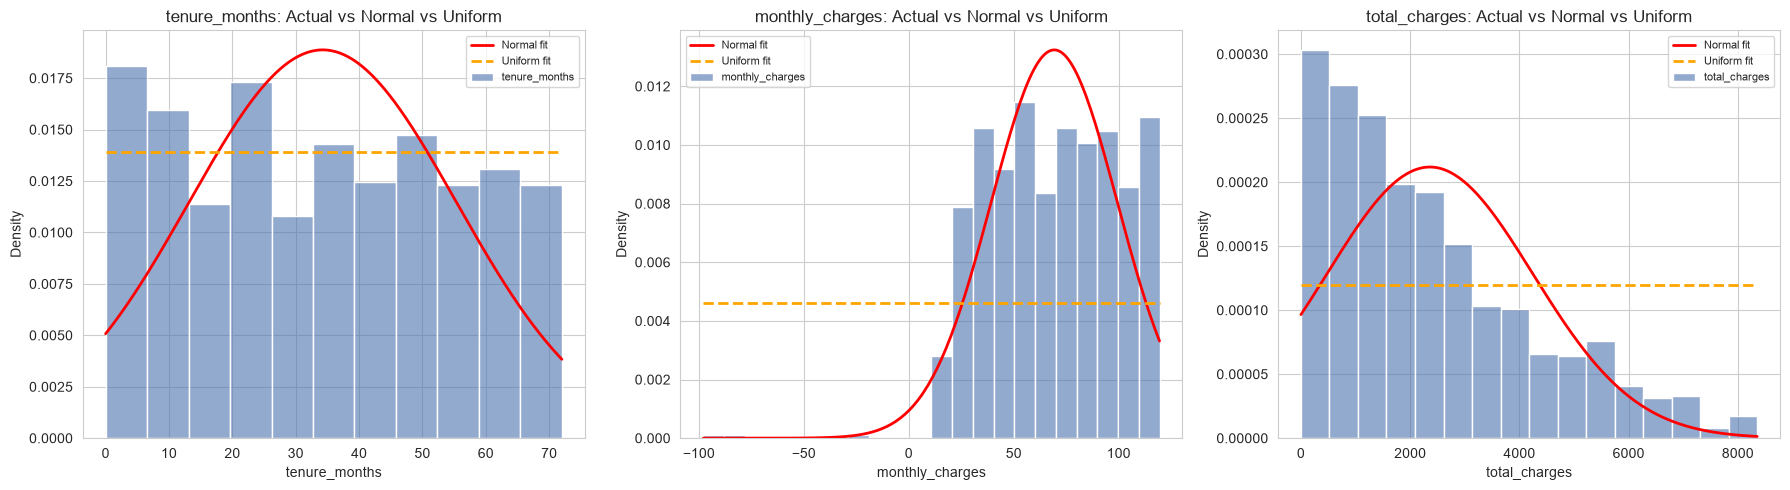

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    data = df[col].dropna()
    sns.histplot(data, stat='density', kde=False, ax=ax, color='#4C72B0',
                 edgecolor='white', alpha=0.6, label=col)

    x = np.linspace(data.min(), data.max(), 200)
    # Matching Normal curve
    ax.plot(x, stats.norm.pdf(x, data.mean(), data.std()), color='red', lw=2, label='Normal fit')
    # Matching Uniform curve
    ax.plot(x, stats.uniform.pdf(x, data.min(), data.max() - data.min()),
            color='orange', lw=2, linestyle='--', label='Uniform fit')

    ax.set_title(f'{col}: Actual vs Normal vs Uniform')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

This overlay makes the earlier interpretation concrete: whichever reference curve (red Normal
vs. orange Uniform) hugs the blue histogram more closely tells us which idealized shape the real
feature resembles most — and for `total_charges`, you can see *neither* curve fits well because of
the pronounced right tail.

## 6. Formal Normality Test (Shapiro-Wilk)

Visual inspection is useful but subjective. The **Shapiro-Wilk test** gives a formal check:
- Null hypothesis (H₀): the data comes from a normal distribution
- If **p-value < 0.05**, we reject H₀ → the data is **not normally distributed**.

In [9]:
from scipy.stats import shapiro

for col in num_cols:
    data = df[col].dropna()
    # Shapiro-Wilk is reliable up to ~5000 samples; our dataset is small enough to test directly
    sample = data if len(data) <= 5000 else data.sample(5000, random_state=42)
    stat, p = shapiro(sample)
    verdict = 'NOT normal (reject H0)' if p < 0.05 else 'Looks normal (fail to reject H0)'
    print(f'{col:18s}  W={stat:.4f}   p-value={p:.6f}   -> {verdict}')

tenure_months       W=0.9517   p-value=0.000000   -> NOT normal (reject H0)
monthly_charges     W=0.9543   p-value=0.000000   -> NOT normal (reject H0)
total_charges       W=0.9126   p-value=0.000000   -> NOT normal (reject H0)


In practice, with this dataset the Shapiro-Wilk test rejects normality for all three features
(p-values well below 0.05) — confirming numerically what the histograms already suggested: none of
these features is a "clean" textbook normal distribution.

## 7. Spread: Boxplots and Outlier Detection (IQR method)

Boxplots visualize the **median, quartiles, and outliers** at a glance. We flag outliers using the
standard **IQR rule**: any point below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is an outlier.

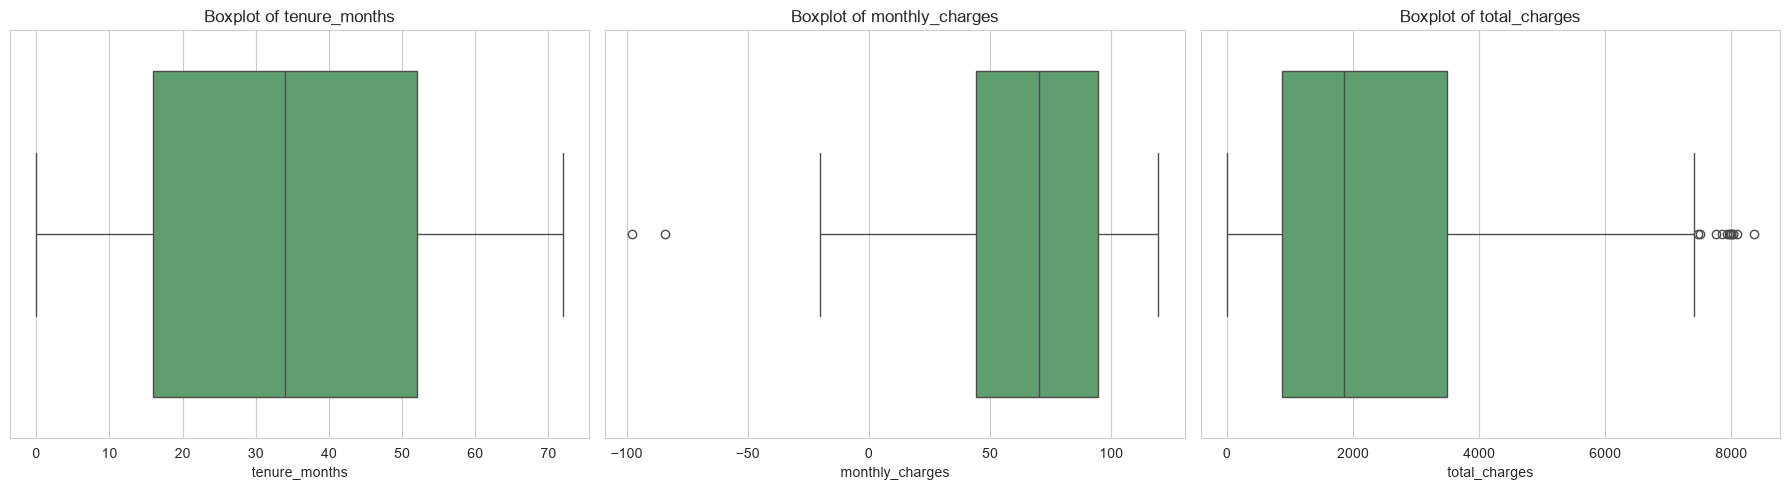

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax, color='#55A868')
    ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [11]:
outlier_summary = []
for col in num_cols:
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = data[(data < lower) | (data > upper)]
    outlier_summary.append({
        'feature': col,
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'lower_bound': lower, 'upper_bound': upper,
        'num_outliers': outliers.shape[0],
        'pct_outliers': round(100 * outliers.shape[0] / len(data), 2)
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('feature')
outlier_df

,Q1,Q3,IQR,lower_bound,upper_bound,num_outliers,pct_outliers
feature,,,,,,,
tenure_months,16.00,52.00,36.00,-38.00,106.00,0,0.00
monthly_charges,44.39,94.37,49.98,-30.57,169.33,2,0.20
total_charges,867.59,"3,486.55","2,618.96","-3,060.85","7,414.99",12,1.22


**Outlier takeaways:**

- `tenure_months` — spread evenly from 0–72; the boxplot typically shows **no or very few
  outliers**, consistent with its flatter/uniform-like shape.
- `monthly_charges` — the boxplot clearly flags the **negative value** as a low-end outlier — this
  is a data-quality issue (a bill amount cannot be negative) and should be corrected or removed
  before modeling.
- `total_charges` — because of the right skew, there may be a handful of **high-end outliers**
  (customers with unusually large cumulative billing), which is expected behavior for an
  accumulating monetary variable rather than a data error.


## 8. Skewness Comparison Chart

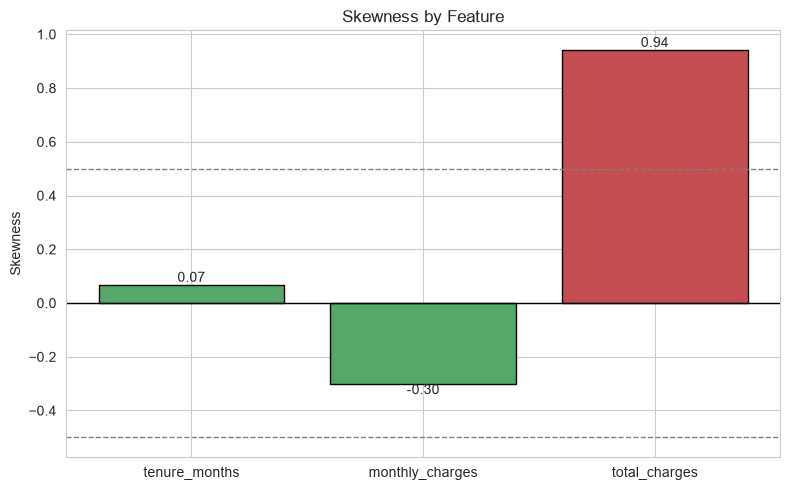

In [12]:
plt.figure(figsize=(8, 5))
colors = ['#c44e52' if s > 0.5 else ('#4c72b0' if s < -0.5 else '#55a868')
          for s in summary_df['skewness']]
bars = plt.bar(summary_df.index, summary_df['skewness'], color=colors, edgecolor='black')
plt.axhline(0, color='black', lw=1)
plt.axhline(0.5, color='gray', linestyle='--', lw=1)
plt.axhline(-0.5, color='gray', linestyle='--', lw=1)
plt.title('Skewness by Feature')
plt.ylabel('Skewness')
for bar, val in zip(bars, summary_df['skewness']):
    plt.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2f}',
              ha='center', va='bottom' if val >= 0 else 'top')
plt.tight_layout()
plt.show()

Green bars ≈ symmetric, red bars = right-skewed, blue bars = left-skewed (thresholds at
±0.5, a common rule-of-thumb boundary for "moderate" skew).